In [1]:
from pystac_client import Client
import odc.stac

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
# Connect to terrabyte STAC

STAC_URL = "https://stac.terrabyte.lrz.de/public/api"

catalog = Client.open(STAC_URL)

print(catalog.title)
print(catalog.description)

terrabyte STAC API
Curated data catalog of the terrabyte platform available at https://stac.terrabyte.lrz.de/public/api


In [3]:
# List available collections

collections = list(catalog.get_all_collections())

print(f"Number of collections: {len(collections)}\n")

for col in collections:
    print(col.id)

Number of collections: 32

viirs-13a1-002
cop-dem-glo-90
viirs-15a2h-002
era5-lowres
sentinel-1-nrb
viirs-09ga-002
sentinel-2-c1-l2a
sentinel-3-olci-l1-efr
esa-worldcover-map-10m-2021-v2
viirs-13a1-001
modis-13a1-061
modis-15a2h-061
landsat-tm-c2-l2
esa-worldcover-map-10m-2020-v1
sentinel-2-c1-l1c
modis-13a2-061
landsat-ot-c2-l1
sentinel-1-slc
modis-13a3-061
viirs-15a2h-001
modis-10a1-061
sentinel-1-grd
modis-09ga-061
modis-09gq-061
landsat-ot-c2-l2
modis-13q1-061
viirs-09ga-001
landsat-etm-c2-l2
cop-dem-glo-30
sentinel-3-slstr-l1-rbt
viirs-10a1-002
sentinel-2-l2a-maja


In [4]:
# Select Sentinek-1 NRB collection

collection_id = "sentinel-1-nrb"

collection = catalog.get_collection(collection_id)

print("Collection ID:", collection.id)
print("Title:", collection.title)
print("Description:", collection.description)

Collection ID: sentinel-1-nrb
Title: Sentinel-1 Normalized Radar Backscatter (NRB)
Description: This is the Sentinel-1 Normalized Radar Backscatter product produced at DLR terrabyte based on Sentinel-1 GRD data. Currently, only selected spatial and temporal areas of interest are available.


In [5]:
bbox = [12.75, 47.45, 13.15, 47.75]
time_range = "2023-06-01/2023-08-31"

In [6]:
# Search items

search = catalog.search(
    collections=[collection_id],
    bbox=bbox,
    datetime=time_range,
    max_items=50
)

items = list(search.items())

print(f"Found {len(items)} Sentinel-1 NRB items")

Found 50 Sentinel-1 NRB items


In [7]:
# Inspect returned items

records = []

for item in items:
    records.append({
        "id": item.id,
        "datetime": item.datetime,
        "platform": item.properties.get("platform"),
        "orbit_state": item.properties.get("sat:orbit_state"),
        "relative_orbit": item.properties.get("sat:relative_orbit"),
        "sar:instrument_mode": item.properties.get("sar:instrument_mode"),
        "sar:polarizations": item.properties.get("sar:polarizations")
    })

items_df = pd.DataFrame(records)
items_df.head(10)

,id,datetime,platform,orbit_state,relative_orbit,sar:instrument_mode,sar:polarizations
0,S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8...,2023-08-31 05:27:13.633848+00:00,sentinel-1a,descending,168,IW,"[VV, VH]"
1,S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8...,2023-08-31 05:27:13.020474+00:00,sentinel-1a,descending,168,IW,"[VV, VH]"
2,S1A_IW_NRB__1SDV_20230831T052658_050115_0607E8...,2023-08-31 05:26:58.732148+00:00,sentinel-1a,descending,168,IW,"[VV, VH]"
3,S1A_IW_NRB__1SDV_20230831T052657_050115_0607E8...,2023-08-31 05:26:57.904313+00:00,sentinel-1a,descending,168,IW,"[VV, VH]"
4,S1A_IW_NRB__1SDV_20230829T165148_050093_060726...,2023-08-29 16:51:48.582000+00:00,sentinel-1a,ascending,146,IW,"[VV, VH]"
5,S1A_IW_NRB__1SDV_20230829T165136_050093_060726...,2023-08-29 16:51:36.015021+00:00,sentinel-1a,ascending,146,IW,"[VV, VH]"
6,S1A_IW_NRB__1SDV_20230829T165121_050093_060726...,2023-08-29 16:51:21.504624+00:00,sentinel-1a,ascending,146,IW,"[VV, VH]"
7,S1A_IW_NRB__1SDV_20230827T170757_050064_060630...,2023-08-27 17:07:57.270179+00:00,sentinel-1a,ascending,117,IW,"[VV, VH]"
8,S1A_IW_NRB__1SDV_20230827T170756_050064_060630...,2023-08-27 17:07:56.555679+00:00,sentinel-1a,ascending,117,IW,"[VV, VH]"
9,S1A_IW_NRB__1SDV_20230827T170742_050064_060630...,2023-08-27 17:07:42.321622+00:00,sentinel-1a,ascending,117,IW,"[VV, VH]"


In [8]:
# Inspect assets

item = items[0]

print("Item ID:", item.id)
print("Datetime:", item.datetime)
print("Properties:")
for key, value in item.properties.items():
    print(f"{key}: {value}")

print("\nAvailable assets:")
for key, asset in item.assets.items():
    print(key, "->", asset.href)

Item ID: S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739
Datetime: 2023-08-31 05:27:13.633848+00:00
Properties:
gsd: 10.0
created: 2026-02-02T20:06:58.084089Z
datetime: 2023-08-31T05:27:13.633848Z
platform: sentinel-1a
proj:bbox: [699960.0, 5190240.0, 809760.0, 5300040.0]
proj:wkt2: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]
proj:shape: [10980, 10980]
instruments: ['c-sar']
end_datetime: 2023-08-31T05:27:31.278882Z
constellation: se

In [9]:
# Find likely VV/VH asset names

available_assets = sorted(item.assets.keys())
available_assets

['acquisition-id',
 'card4l',
 'cc-g-lin',
 'contributing-area',
 'data-mask',
 'gamma-sigma-ratio',
 'local-incidence-angle',
 'vh-g-lin',
 'vh-g-log',
 'vh-s-lin',
 'vh-s-log',
 'vv-g-lin',
 'vv-g-log',
 'vv-s-lin',
 'vv-s-log']

In [10]:
# Helper: find possible asset names containing vv or vh
vv_candidates = [a for a in available_assets if "vv" in a.lower()]
vh_candidates = [a for a in available_assets if "vh" in a.lower()]

print("VV candidates:", vv_candidates)
print("VH candidates:", vh_candidates)

VV candidates: ['vv-g-lin', 'vv-g-log', 'vv-s-lin', 'vv-s-log']
VH candidates: ['vh-g-lin', 'vh-g-log', 'vh-s-lin', 'vh-s-log']


In [11]:
# Define selected SAR bands

vv_band = vv_candidates[0]
vh_band = vh_candidates[0]

bands = [vv_band, vh_band]

print("Using bands:", bands)

Using bands: ['vv-g-lin', 'vh-g-lin']


In [12]:
ds = odc.stac.load(
    items,
    bands=bands,
    bbox=bbox,
    resolution=10,
    chunks={"x": 1024, "y": 1024}
)

ds

<xarray.Dataset> Size: 4GB
Dimensions:      (y: 3414, x: 3096, time: 50)
Coordinates:
  * y            (y) float64 27kB 5.291e+06 5.291e+06 ... 5.257e+06 5.257e+06
  * x            (x) float64 25kB 3.304e+05 3.304e+05 ... 3.613e+05 3.613e+05
  * time         (time) datetime64[us] 400B 2023-08-03T17:07:56.404307 ... 20...
    spatial_ref  int32 4B 32633
Data variables:
    vv-g-lin     (time, y, x) float32 2GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    vh-g-lin     (time, y, x) float32 2GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

In [13]:
# Inspect values

for band in bands:
    arr = ds[band]
    print(
        band,
        "min:", float(arr.min().compute()),
        "max:", float(arr.max().compute()),
        "mean:", float(arr.mean().compute())
    )

Aborting load due to failure while reading: file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230814T051902_049867_05FF6B_32TQT_6B60/measurement/s1a-iw-nrb-20230814t051902-049867-05ff6b-32tqt-vv-g-lin.tif:1
Aborting load due to failure while reading: file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230815T170740_049889_060031_32TQT_DB5D/measurement/s1a-iw-nrb-20230815t170740-049889-060031-32tqt-vv-g-lin.tif:1
Aborting load due to failure while reading: file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/33/T/UN/2023/08/S1A_IW_NRB__1SDV_20230815T170741_049889_060031_33TUN_A725/measurement/s1a-iw-nrb-20230815t170741-049889-060031-33tun-vv-g-lin.tif:1
Aborting load due to failure while reading: file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/33/T/UN/2023/08/S1A_IW_NRB__1SDV_20230814T051859_049867_05FF6B_33TUN_55B5/measurement/s1a-iw-nrb-20230814t051859

RasterioIOError: /dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230814T051902_049867_05FF6B_32TQT_6B60/measurement/s1a-iw-nrb-20230814t051902-049867-05ff6b-32tqt-vv-g-lin.tif: No such file or directory

In [14]:
from pathlib import Path

href = items[0].assets[vv_band].href
print("Original href:")
print(href)

local_path = href.replace(
    "file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles",
    "/mnt/dss_nrb/Sentinel-1/NRB/tiles"
)

print("\nLocal path:")
print(local_path)

print("\nExists:", Path(local_path).exists())

Original href:
file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-32tqt-vv-g-lin.tif

Local path:
/mnt/dss_nrb/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-32tqt-vv-g-lin.tif

Exists: True


In [15]:
def rewrite_nrb_href_to_local_mount(item):
    """
    Rewrite terrabyte Sentinel-1 NRB STAC file:// hrefs
    to local file:// hrefs on trieste.
    """
    item = item.clone()

    old_prefix = "file:///dss/dsstbyfs03/pn56su/pn56su-dss-0023/Sentinel-1/NRB/tiles"
    new_prefix = "file:///mnt/dss_nrb/Sentinel-1/NRB/tiles"

    for asset in item.assets.values():
        if asset.href.startswith(old_prefix):
            asset.href = asset.href.replace(old_prefix, new_prefix)

    return item


items_local = [rewrite_nrb_href_to_local_mount(item) for item in items]

In [16]:
from pathlib import Path

for item in items_local[:5]:
    print("\nItem:", item.id)
    for band in bands:
        href = item.assets[band].href
        print(band, Path(href).exists(), href)


Item: S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739
vv-g-lin False file:///mnt/dss_nrb/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-32tqt-vv-g-lin.tif
vh-g-lin False file:///mnt/dss_nrb/Sentinel-1/NRB/tiles/32/T/QT/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_32TQT_D739/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-32tqt-vh-g-lin.tif

Item: S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_33TUN_BA68
vv-g-lin False file:///mnt/dss_nrb/Sentinel-1/NRB/tiles/33/T/UN/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_33TUN_BA68/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-33tun-vv-g-lin.tif
vh-g-lin False file:///mnt/dss_nrb/Sentinel-1/NRB/tiles/33/T/UN/2023/08/S1A_IW_NRB__1SDV_20230831T052713_050115_0607E8_33TUN_BA68/measurement/s1a-iw-nrb-20230831t052713-050115-0607e8-33tun-vh-g-lin.tif

Item: S1A_IW_NRB__1SDV_20230831T052658_050115_0607E8_32UQU_84

In [17]:
ds_test = odc.stac.load(
    items_local[:1],
    bands=bands,
    bbox=bbox,
    chunks={"x": 1024, "y": 1024}
)

ds_test

<xarray.Dataset> Size: 89MB
Dimensions:      (y: 3487, x: 3177, time: 1)
Coordinates:
  * y            (y) float64 28kB 5.297e+06 5.297e+06 ... 5.262e+06 5.262e+06
  * x            (x) float64 25kB 7.811e+05 7.811e+05 ... 8.128e+05 8.128e+05
  * time         (time) datetime64[us] 8B 2023-08-31T05:27:13.633848
    spatial_ref  int32 4B 32632
Data variables:
    vv-g-lin     (time, y, x) float32 44MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    vh-g-lin     (time, y, x) float32 44MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

In [18]:
ds = odc.stac.load(
    items_local,
    bands=bands,
    bbox=bbox,
    chunks={"x": 1024, "y": 1024}
)

ds

<xarray.Dataset> Size: 4GB
Dimensions:      (y: 3414, x: 3096, time: 50)
Coordinates:
  * y            (y) float64 27kB 5.291e+06 5.291e+06 ... 5.257e+06 5.257e+06
  * x            (x) float64 25kB 3.304e+05 3.304e+05 ... 3.613e+05 3.613e+05
  * time         (time) datetime64[us] 400B 2023-08-03T17:07:56.404307 ... 20...
    spatial_ref  int32 4B 32633
Data variables:
    vv-g-lin     (time, y, x) float32 2GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    vh-g-lin     (time, y, x) float32 2GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

In [19]:
vv = ds[vv_band].astype("float32")
vh = ds[vh_band].astype("float32")

vv_db = 10 * np.log10(vv.where(vv > 0))
vh_db = 10 * np.log10(vh.where(vh > 0))

In [20]:
vv_median = vv_db.median(dim="time", skipna=True)
vh_median = vh_db.median(dim="time", skipna=True)

/mnt/dss_project/lmandl/anaconda3/envs/terrabyte/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
/mnt/dss_project/lmandl/anaconda3/envs/terrabyte/lib/python3.11/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


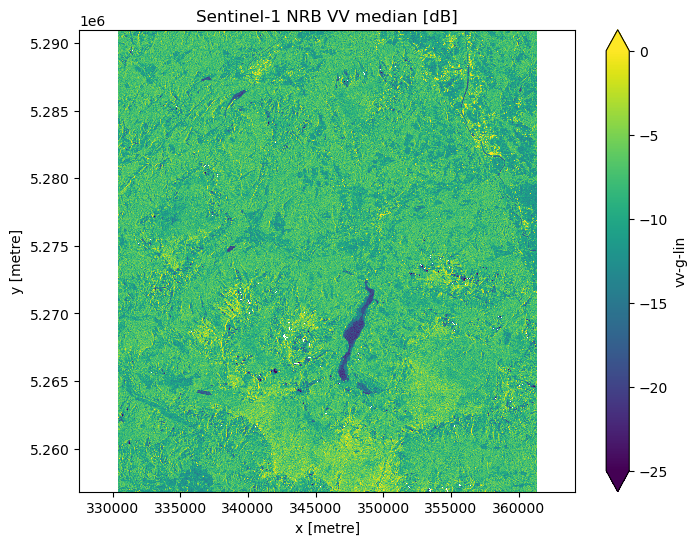

In [21]:
plt.figure(figsize=(8, 6))
vv_median.plot.imshow(vmin=-25, vmax=0)
plt.title("Sentinel-1 NRB VV median [dB]")
plt.axis("equal")
plt.show()

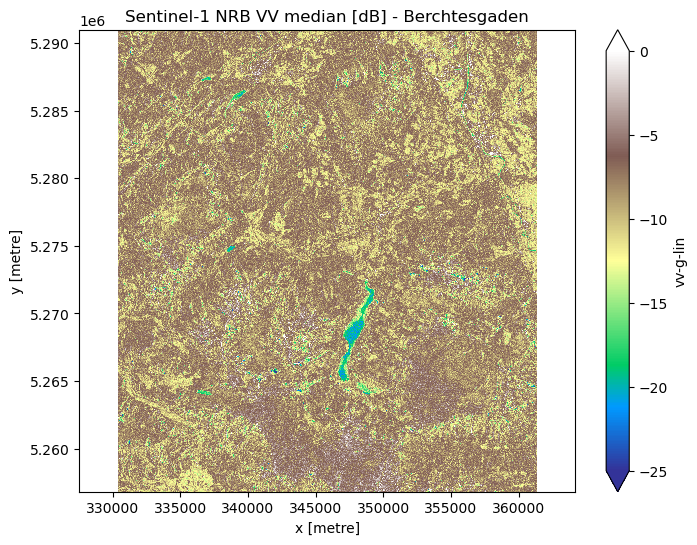

In [24]:
plt.figure(figsize=(8, 6))

vv_median.plot.imshow(
    vmin=-25,
    vmax=0,
    cmap="terrain"
)

plt.xlim(12.75, 13.15)
plt.ylim(47.45, 47.75)

plt.title("Sentinel-1 NRB VV median [dB] - Berchtesgaden")
plt.axis("equal")
plt.show()

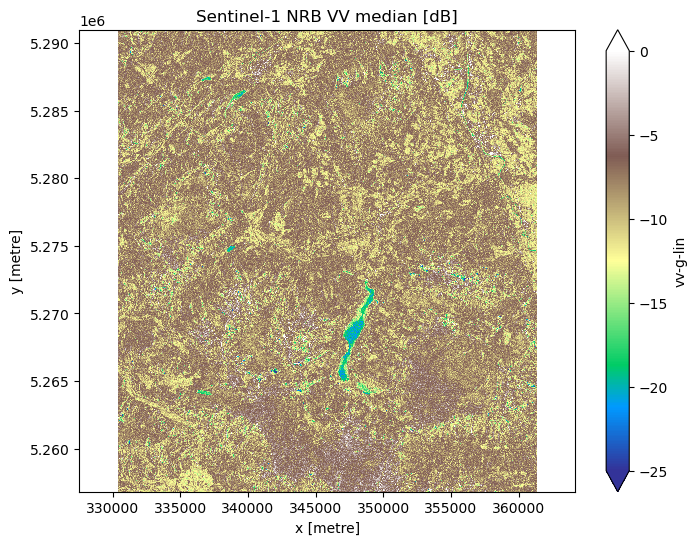

In [25]:
plt.figure(figsize=(8, 6))

vv_median.plot.imshow(
    vmin=-25,
    vmax=0,
    cmap="terrain"
)

plt.xlim(12.95, 13.05)
plt.ylim(47.58, 47.68)

plt.title("Sentinel-1 NRB VV median [dB]")
plt.axis("equal")

plt.savefig(
    "sentinel1_vv_berchtesgaden_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
import rioxarray
from pyproj import Transformer

# lon/lat bbox für Berchtesgaden
lon_min, lat_min, lon_max, lat_max = 12.95, 47.58, 13.05, 47.68

# Transformation von WGS84 -> UTM 33N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32633", always_xy=True)

x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

print("Transformed bbox:")
print(x_min, y_min, x_max, y_max)

Transformed bbox:
345845.0740327628 5271656.9453005055 353644.1084469999 5282576.380159706


In [32]:
vv_zoom = vv_median.sel(
    x=slice(min(x_min, x_max), max(x_min, x_max)),
    y=slice(max(y_min, y_max), min(y_min, y_max))   # weil y bei dir absteigend ist
)

print(vv_zoom.shape)
print(vv_zoom.sizes)

(1092, 779)
Frozen({'y': 1092, 'x': 779})


In [33]:
vv_zoom.rio.to_raster(
    "sentinel1_vv_median_berchtesgaden_zoom.tif",
    driver="GTiff",
    dtype="float32",
    compress="LZW"
)

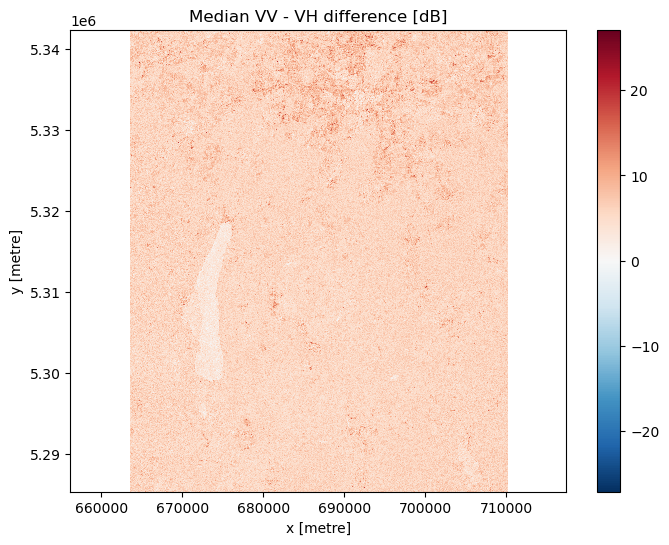

In [30]:
vv_vh_diff = vv_db - vh_db
vv_vh_diff_median = vv_vh_diff.median(dim="time", skipna=True)

plt.figure(figsize=(8, 6))
vv_vh_diff_median.plot.imshow()
plt.title("Median VV - VH difference [dB]")
plt.axis("equal")
plt.show()